# EDA — Playground Series S6E6 (Stellar Classification)

Doel: nieuwe features ontdekken die de balanced accuracy van het XGB model verbeteren.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
CLASS_ORDER = ['GALAXY', 'QSO', 'STAR']
BAND_COLS = ['u', 'g', 'r', 'i', 'z']
LABEL_MAP = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}

In [4]:
import os

os.chdir("/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/notebooks")

In [5]:
train = pd.read_csv('../data/train.csv', index_col='id')
test  = pd.read_csv('../data/test.csv',  index_col='id')
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()

y = train['class'].map(LABEL_MAP)

print(f'train: {train.shape}   test: {test.shape}')
train.dtypes

train: (577347, 11)   test: (247435, 10)


alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object
dtype: object

---
## 1. Data overview

In [6]:
# Missing values
print('Nulls:')
print(train.isnull().sum().to_string())
print()
# Target distribution
print('Class distribution:')
print(train['class'].value_counts())

Nulls:
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0

Class distribution:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


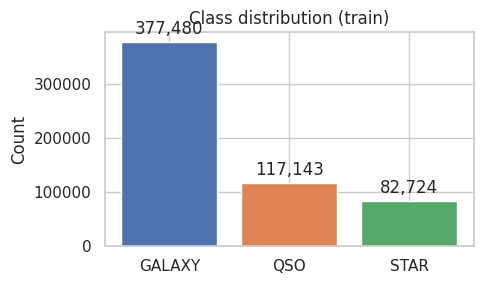

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
counts = train['class'].value_counts()[CLASS_ORDER]
bars = ax.bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Class distribution (train)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Klasse-imbalans:** GALAXY domineert (~65%), STAR het minst (~14%). `sample_weight='balanced'` is noodzakelijk bij XGB.

---
## 2. Categorische features

`spectral_type` en `galaxy_population` zijn de enige categorische kolommen.

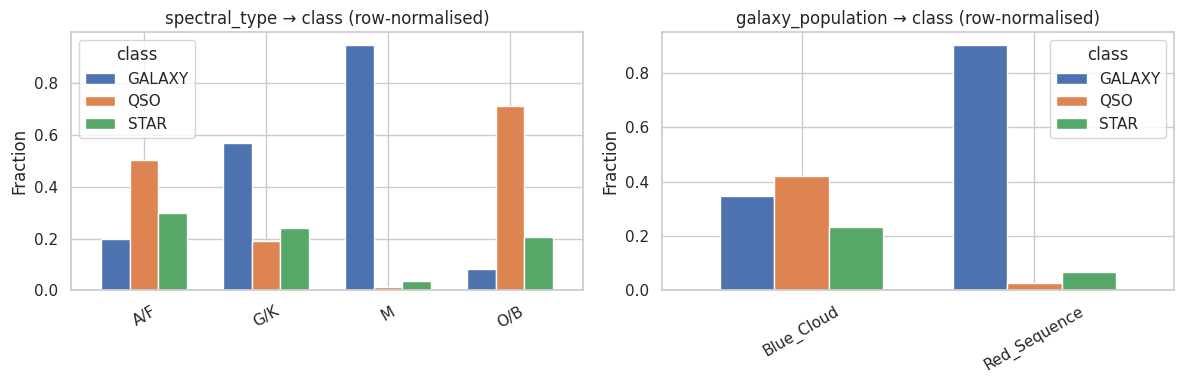

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['spectral_type', 'galaxy_population']):
    ct = pd.crosstab(train[col], train['class'], normalize='index')[CLASS_ORDER]
    ct.plot(kind='bar', ax=ax, color=[PALETTE[c] for c in CLASS_ORDER], width=0.7)
    ax.set_title(f'{col} → class (row-normalised)')
    ax.set_ylabel('Fraction')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='class')

plt.tight_layout()
plt.show()

**Bevindingen:**
- `spectral_type=M` → bijna altijd GALAXY (95%). `O/B` → merendeels QSO (71%).
- `galaxy_population=Red_Sequence` → bijna altijd GALAXY (90%). Blue_Cloud is gemengd.

**Feature idee:** combinatiekolom `spectral_type × galaxy_population` geeft 8 unieke groepen met sterk verschillende class-verdelingen.

In [9]:
train['sp_gp'] = train['spectral_type'] + '_' + train['galaxy_population']
ct = pd.crosstab(train['sp_gp'], train['class'], normalize='index')[CLASS_ORDER]
ct.style.background_gradient(cmap='Blues', axis=1)

class,GALAXY,QSO,STAR
sp_gp,,,
A/F_Blue_Cloud,0.182138,0.524054,0.293809
A/F_Red_Sequence,0.370888,0.289225,0.339887
G/K_Blue_Cloud,0.439860,0.284020,0.276119
G/K_Red_Sequence,0.750919,0.062001,0.187080
M_Blue_Cloud,0.924101,0.036079,0.039819
M_Red_Sequence,0.953438,0.009278,0.037285
O/B_Blue_Cloud,0.082173,0.715819,0.202009
O/B_Red_Sequence,0.106140,0.526316,0.367544


---
## 3. Redshift — meest informatieve numerieke feature

In [10]:
print('Redshift statistieken per klasse:')
print(train.groupby('class')['redshift'].describe()[['mean','std','min','50%','max']])

Redshift statistieken per klasse:
         mean    std     min    50%    max
class                                     
GALAXY 0.5090 0.3091 -0.0099 0.4820 6.8603
QSO    1.8756 1.0697  0.0001 1.7989 7.0108
STAR   0.0681 0.0645 -0.0100 0.0565 5.4452


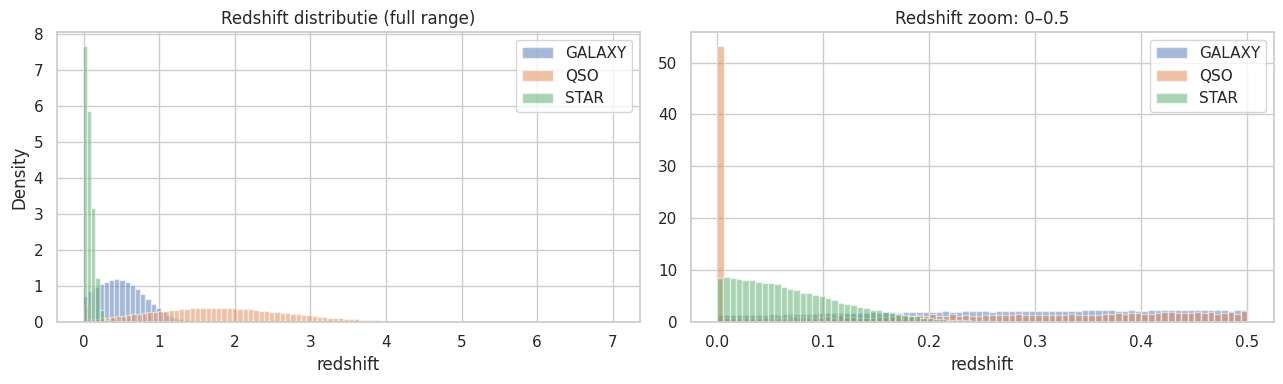

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full range histogram
for cls in CLASS_ORDER:
    axes[0].hist(train.loc[train['class']==cls, 'redshift'],
                 bins=100, alpha=0.5, label=cls, color=PALETTE[cls], density=True)
axes[0].set_title('Redshift distributie (full range)')
axes[0].set_xlabel('redshift')
axes[0].set_ylabel('Density')
axes[0].legend()

# Zoom: 0..0.5 (STAR/GALAXY overlap)
for cls in CLASS_ORDER:
    sub = train.loc[(train['class']==cls) & (train['redshift'] >= 0) & (train['redshift'] <= 0.5), 'redshift']
    axes[1].hist(sub, bins=80, alpha=0.5, label=cls, color=PALETTE[cls], density=True)
axes[1].set_title('Redshift zoom: 0–0.5')
axes[1].set_xlabel('redshift')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
bins = [-1, 0.01, 0.1, 0.5, 1.0, 2.0, 10]
labels = ['<0.01', '0.01–0.1', '0.1–0.5', '0.5–1', '1–2', '>2']
train['rz_bin'] = pd.cut(train['redshift'], bins=bins, labels=labels)
ct = pd.crosstab(train['rz_bin'], train['class'], normalize='index')[CLASS_ORDER]
print('Class-verdeling per redshift-bin:')
ct.style.background_gradient(cmap='Blues', axis=1)

Class-verdeling per redshift-bin:


class,GALAXY,QSO,STAR
rz_bin,,,
<0.01,0.236007,0.159867,0.604126
0.01–0.1,0.350948,0.011114,0.637938
0.1–0.5,0.857467,0.031236,0.111297
0.5–1,0.917050,0.082920,0.000030
1–2,0.375794,0.624149,0.000058
>2,0.000767,0.999173,0.000061


**Bevindingen:**
- `redshift > 2` → vrijwel zeker QSO (99.9%). `redshift < 0.01` → voornamelijk STAR (60%).
- ~8 957 objecten hebben negatieve redshift; dit zijn bijna uitsluitend STARs en een kleine groep GALAXYs (meetfout/ruis).

**Feature ideeën:**
- `log1p(|redshift|)` compresseert de lange staart.
- Binaire vlaggen: `is_very_low_z = redshift < 0.05`, `is_high_z = redshift > 1.5`.

---
## 4. Kleurindices (fotometrische bands)

In de astronomie zijn *kleurindices* (bandverschillen) standaard diagnostische grootheden. Ze zijn redshift-onafhankelijker dan absolute magnitudes.

In [13]:
for col in ['u_g','g_r','r_i','i_z','g_z','u_r','g_i']:
    b1, b2 = col.split('_')
    train[col] = train[b1] - train[b2]

COLOR_COLS = ['u_g', 'g_r', 'r_i', 'i_z', 'g_z', 'u_r', 'g_i']

print('Gemiddelde kleurindex per klasse:')
train.groupby('class')[COLOR_COLS].mean().round(3)

Gemiddelde kleurindex per klasse:


,u_g,g_r,r_i,i_z,g_z,u_r,g_i
class,,,,,,,
GALAXY,1.7190,1.4100,0.7920,0.4380,2.6400,3.1290,2.2020
QSO,0.5640,0.2420,0.1510,0.1650,0.5580,0.8060,0.3930
STAR,1.3690,0.5150,0.2450,0.1230,0.8840,1.8850,0.7600


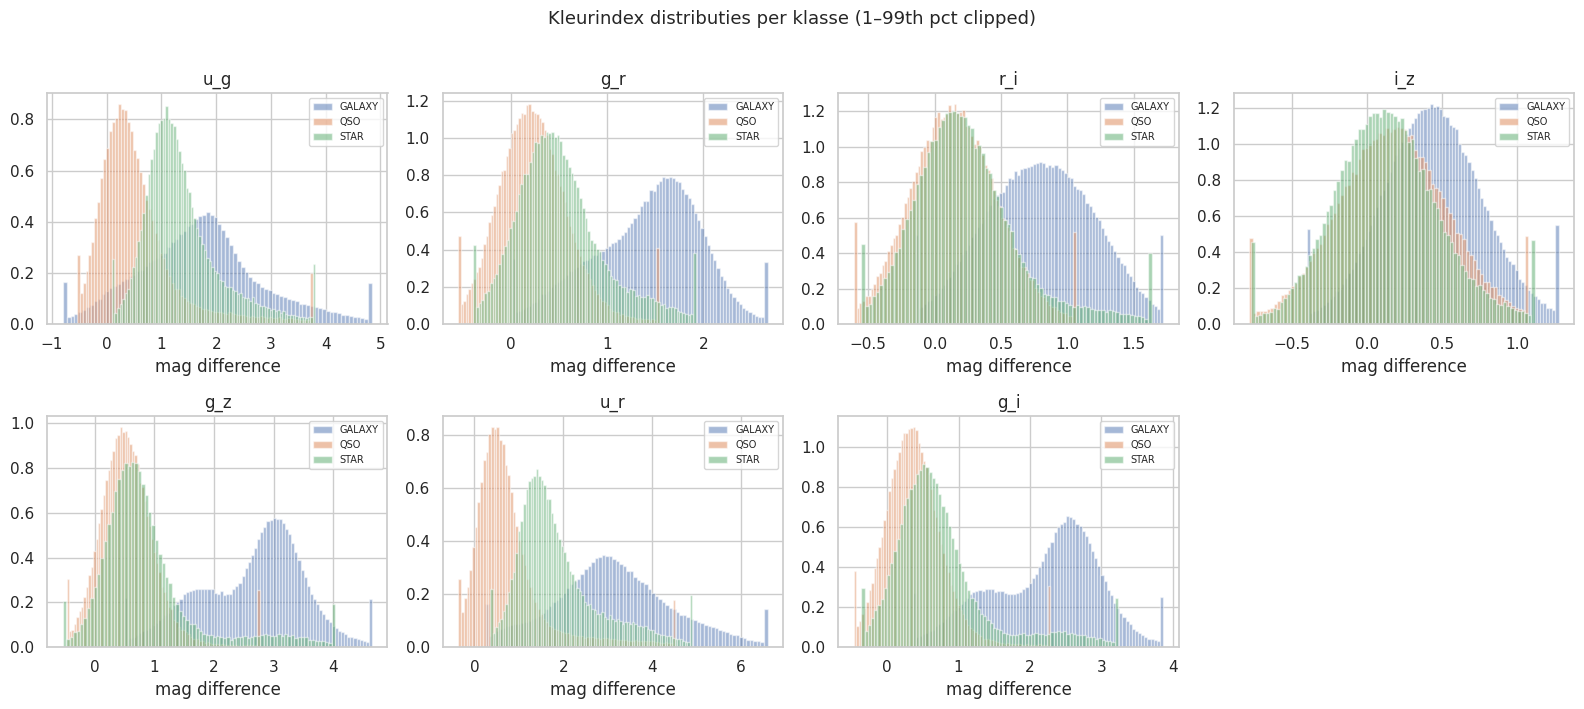

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, COLOR_COLS):
    for cls in CLASS_ORDER:
        vals = train.loc[train['class']==cls, col]
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=80, alpha=0.5, label=cls, color=PALETTE[cls], density=True)
    ax.set_title(col)
    ax.set_xlabel('mag difference')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Kleurindex distributies per klasse (1–99th pct clipped)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Bevindingen:**
- `g_z` en `g_i` zijn de beste separatoren (Spearman |r| > 0.69).
- GALAXYs zijn rood (`g_z > 2`), QSOs zijn blauw (`g_z < 0.6`).
- Alle kleurindices zijn gecorreleerd met elkaar; `g_z` is grotendeels een lineaire combinatie van de overige.

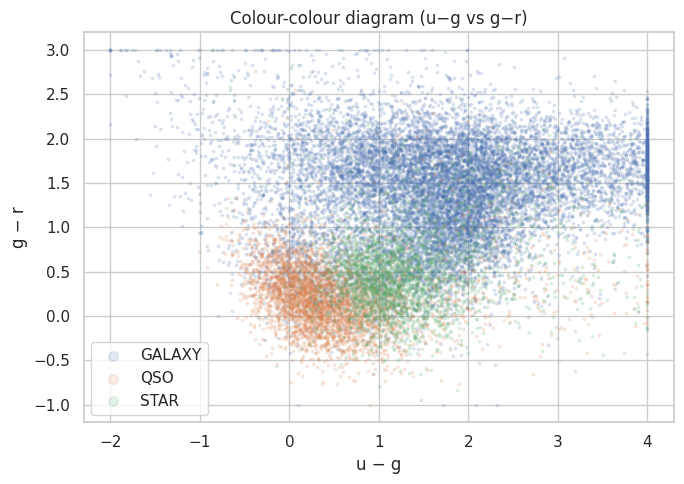

In [15]:
# Klassiek colour-colour diagram: g-r vs u-g
fig, ax = plt.subplots(figsize=(7, 5))
sample = train.sample(20000, random_state=42)

for cls in CLASS_ORDER:
    sub = sample[sample['class']==cls]
    ax.scatter(sub['u_g'].clip(-2, 4), sub['g_r'].clip(-1, 3),
               alpha=0.15, s=3, label=cls, color=PALETTE[cls])

ax.set_xlabel('u − g')
ax.set_ylabel('g − r')
ax.set_title('Colour-colour diagram (u−g vs g−r)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

STARs en QSOs overlappen sterk in het klassieke u−g / g−r diagram. `g_z` geeft betere scheiding.

---
## 5. Magnitudestatistieken over bands

In [16]:
train['mag_mean']  = train[BAND_COLS].mean(axis=1)
train['mag_std']   = train[BAND_COLS].std(axis=1)
train['mag_range'] = train[BAND_COLS].max(axis=1) - train[BAND_COLS].min(axis=1)
# color_slope: gemiddelde helling over de 5 bands (ugriz)
train['color_slope'] = (train['u'] - train['z']) / 4

AGG_COLS = ['mag_mean', 'mag_std', 'mag_range', 'color_slope']

print('Gemiddelde per klasse:')
train.groupby('class')[AGG_COLS].mean().round(3)

Gemiddelde per klasse:


,mag_mean,mag_std,mag_range,color_slope
class,,,,
GALAXY,20.3640,1.8200,4.4060,1.0900
QSO,21.0350,0.5180,1.2840,0.2810
STAR,19.4330,0.9600,2.3740,0.5630


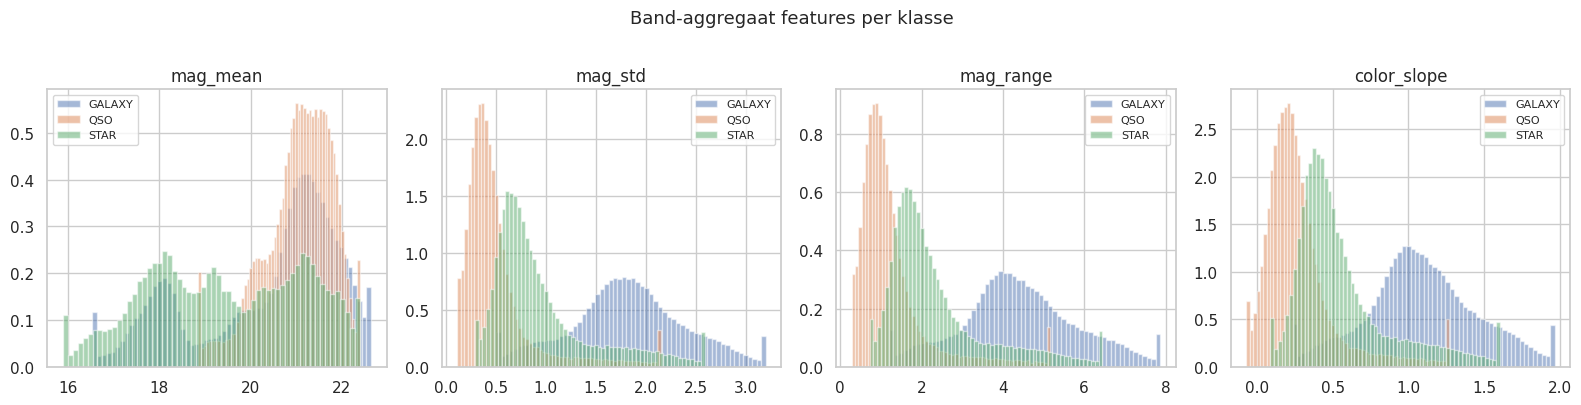

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, AGG_COLS):
    for cls in CLASS_ORDER:
        vals = train.loc[train['class']==cls, col]
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=60, alpha=0.5, label=cls, color=PALETTE[cls], density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Band-aggregaat features per klasse', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Bevindingen:**
- `mag_std` (Spearman |r|=0.64): QSOs hebben de laagste spreiding over bands (vlak spectrum), GALAXYs de hoogste.
- `mag_range` is sterk gecorreleerd met `mag_std` (beide meten kleurspectrum-breedte).
- `color_slope` = (u−z)/4 is equivalent aan de kleurindex-helling en bijna identiek aan `g_z`.

---
## 6. Redshift-interacties met kleur

In [18]:
train['log_redshift']  = np.log1p(np.abs(train['redshift']))
train['redshift_g_r']  = train['redshift'] * train['g_r']
train['redshift_g_z']  = train['redshift'] * train['g_z']
train['redshift_u_r']  = train['redshift'] * train['u_r']

INTERACT_COLS = ['log_redshift', 'redshift_g_r', 'redshift_g_z', 'redshift_u_r']
print('Gemiddelde per klasse:')
train.groupby('class')[INTERACT_COLS].mean().round(3)

Gemiddelde per klasse:


,log_redshift,redshift_g_r,redshift_g_z,redshift_u_r
class,,,,
GALAXY,0.3910,0.7270,1.4040,1.5260
QSO,0.9840,0.4830,1.1000,1.8930
STAR,0.0650,0.0350,0.0600,0.1250


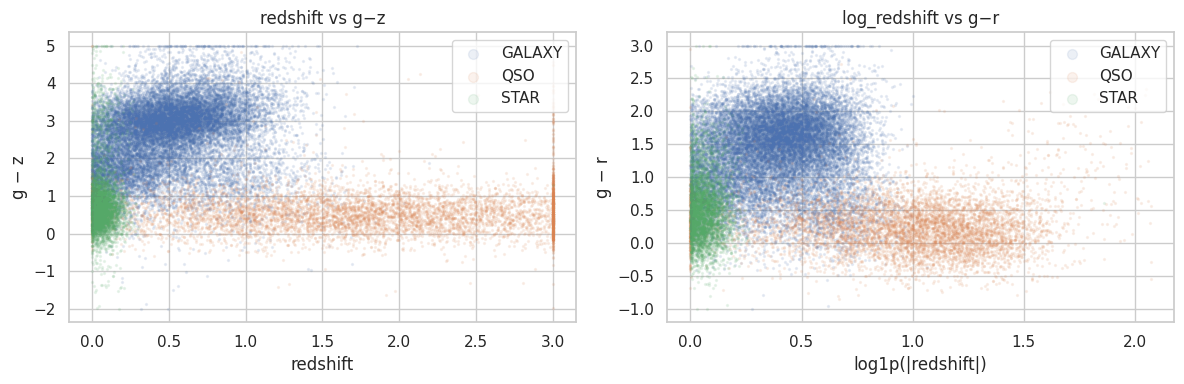

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = train.sample(30000, random_state=0)

for cls in CLASS_ORDER:
    sub = sample[sample['class']==cls]
    axes[0].scatter(sub['redshift'].clip(0, 3), sub['g_z'].clip(-2, 5),
                    alpha=0.1, s=2, label=cls, color=PALETTE[cls])
    axes[1].scatter(sub['log_redshift'], sub['g_r'].clip(-1, 3),
                    alpha=0.1, s=2, label=cls, color=PALETTE[cls])

axes[0].set_xlabel('redshift')
axes[0].set_ylabel('g − z')
axes[0].set_title('redshift vs g−z')
axes[0].legend(markerscale=5)

axes[1].set_xlabel('log1p(|redshift|)')
axes[1].set_ylabel('g − r')
axes[1].set_title('log_redshift vs g−r')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

**Bevindingen:**
- Bij lage redshift (< 0.1) overlappen STAR en GALAXY sterk in kleur. De interactie `redshift × g_z` helpt XGB dit onderscheid te leren.
- QSOs zitten in een apart gebied (hoge redshift + lage g_z).

---
## 7. Hemelcoördinaten (alpha, delta)

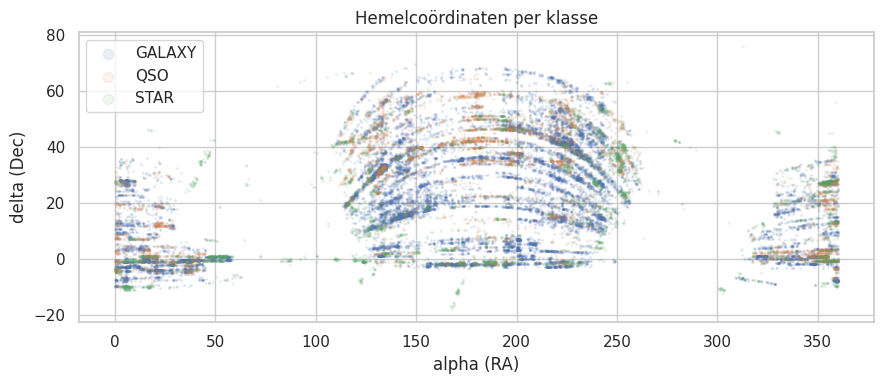

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
sample = train.sample(30000, random_state=1)

for cls in CLASS_ORDER:
    sub = sample[sample['class']==cls]
    ax.scatter(sub['alpha'], sub['delta'], alpha=0.1, s=1.5, label=cls, color=PALETTE[cls])

ax.set_xlabel('alpha (RA)')
ax.set_ylabel('delta (Dec)')
ax.set_title('Hemelcoördinaten per klasse')
ax.legend(markerscale=6)
plt.tight_layout()
plt.show()

In [21]:
print('Alpha/delta statistieken per klasse:')
train.groupby('class')[['alpha','delta']].agg(['mean','std']).round(3)

Alpha/delta statistieken per klasse:


alpha            delta        
           mean      std    mean     std
class                                   
GALAXY 178.5570  91.8310 21.0330 18.4810
QSO    189.6660 103.4710 25.8120 19.5830
STAR   184.1790 104.2310 19.8590 19.2640

**Bevinding:** De klassen zijn vrijwel uniform verdeeld over de hemel. Alpha en delta hebben een lage Spearman-correlatie (< 0.04) met de target. Ze voegen weinig informatiewaarde toe.

---
## 8. Spearman-correlaties met target

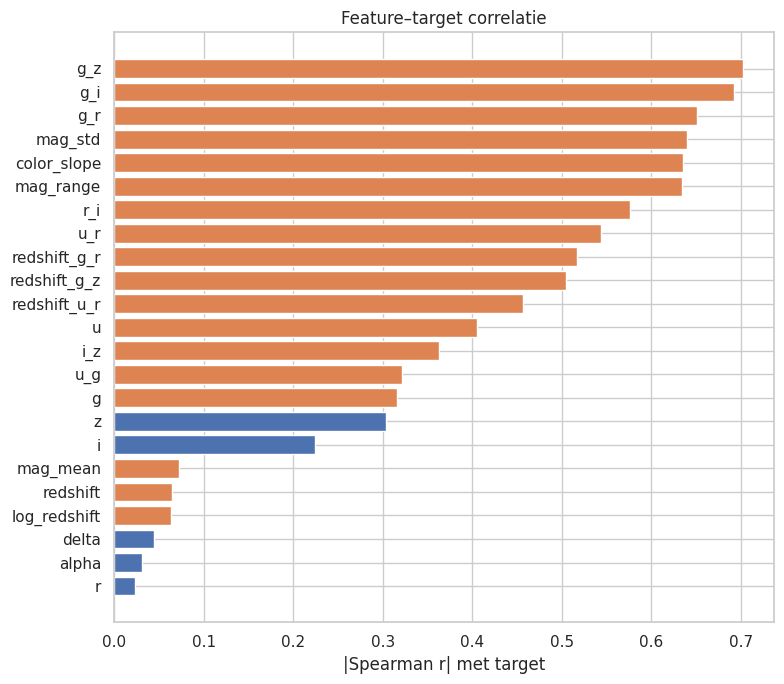

,feature,spearman_abs,spearman
12,g_z,0.7021,-0.7021
14,g_i,0.6930,-0.6930
9,g_r,0.6509,-0.6509
16,mag_std,0.6400,-0.6400
18,color_slope,0.6350,-0.6350
17,mag_range,0.6342,-0.6342
10,r_i,0.5760,-0.5760
13,u_r,0.5434,-0.5434
20,redshift_g_r,0.5165,-0.5165
21,redshift_g_z,0.5042,-0.5042


In [22]:
ALL_FEAT = (
    ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
    + COLOR_COLS
    + AGG_COLS
    + INTERACT_COLS
)

corr_results = []
for col in ALL_FEAT:
    r, _ = spearmanr(train[col].fillna(0), y)
    corr_results.append({'feature': col, 'spearman_abs': abs(r), 'spearman': r})

corr_df = pd.DataFrame(corr_results).sort_values('spearman_abs', ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#DD8452' if r < 0 else '#4C72B0' for r in corr_df['spearman']]
ax.barh(corr_df['feature'], corr_df['spearman_abs'], color=colors)
ax.set_xlabel('|Spearman r| met target')
ax.set_title('Feature–target correlatie')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

corr_df[['feature','spearman_abs','spearman']].head(15)

---
## 9. Samenvatting: feature engineering kandidaten

### Bevestigde features (gevalideerd via XGB 5-fold CV)

| Feature | Type | Motivatie |
|---|---|---|
| `u_g`, `g_r`, `r_i`, `i_z` | kleurindex | Standaard SDSS kleuren, hoge discriminerende kracht |
| `g_z`, `u_r`, `g_i` | kleurindex (breed) | Hoge Spearman |r| (0.65–0.70) |
| `mag_std` | bandaggregaat | QSOs hebben vlak spectrum, laagste std |
| `mag_range` | bandaggregaat | Gecorreleerd met `mag_std`; extra breedte-signal |
| `log_redshift` | transformatie | Comprimeert lange staart; Spearman-neutraal maar helpt bomen |
| `redshift_g_r` | interactie | Combineert redshift + kleur voor STAR/GALAXY overlap |
| `redshift_g_z` | interactie | Sterkste interactie-feature |
| `color_slope` | afgeleid | Equivalent aan (u−z)/4, samenvatting van kleurspectrum |

**Baseline CV:** 0.96050  →  **Met bovenstaande features:** 0.96239  (+0.0019)

### Extra kandidaten om te testen

| Feature | Motivatie |
|---|---|
| `spectral_type × galaxy_population` (OHE) | 8 groepen met sterk onderscheidende class-verdelingen |
| `is_very_low_z` = (redshift < 0.05) | Splitst de lastige STAR/GALAXY overlap bij lage redshift |
| `is_high_z` = (redshift > 1.5) | Bijna zeker QSO; expliciete vlag kan helpen |
| `redshift_u_r` | Interactie voor STAR-isolatie |
| `g_r × g_z` | Niet-lineaire kleurinteractie |

---
## 10. XGB validatie: baseline vs. feature-engineered

In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

XGB_PARAMS = dict(
    objective='multi:softprob', num_class=3,
    tree_method='hist', device='gpu',
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

def run_cv(X, label=''):
    oof = np.zeros((len(X), 3))
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
        w = compute_sample_weight('balanced', ytr)
        m = XGBClassifier(**XGB_PARAMS)
        m.fit(Xtr, ytr, sample_weight=w, eval_set=[(Xva, yva)], verbose=0)
        oof[va_idx] = m.predict_proba(Xva)
    score = balanced_accuracy_score(y, np.argmax(oof, axis=1))
    print(f'{label:25s}  balanced_accuracy = {score:.5f}')
    return score, oof

In [24]:
# Baseline feature set (zelfde als model_baseline.ipynb)
ohe = pd.get_dummies(train[['spectral_type', 'galaxy_population']], drop_first=True, dtype=int)
ohe.columns = ohe.columns.str.lower()

X_base = pd.concat([train[['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']], ohe], axis=1)

# Engineered feature set
X_eng = X_base.copy()
for col in COLOR_COLS + AGG_COLS + INTERACT_COLS:
    X_eng[col] = train[col]

# Extra kandidaten
X_extra = X_eng.copy()
X_extra['is_very_low_z'] = (train['redshift'] < 0.05).astype(int)
X_extra['is_high_z']     = (train['redshift'] > 1.5).astype(int)
# OHE van de combinatiekolom
sp_gp_ohe = pd.get_dummies(train['sp_gp'], drop_first=True, dtype=int)
sp_gp_ohe.columns = sp_gp_ohe.columns.str.lower()
X_extra = pd.concat([X_extra, sp_gp_ohe], axis=1)

print('Feature counts — base:', X_base.shape[1], '  eng:', X_eng.shape[1], '  extra:', X_extra.shape[1])

Feature counts — base: 12   eng: 27   extra: 36


In [25]:
score_base,  oof_base  = run_cv(X_base,  'Baseline')
score_eng,   oof_eng   = run_cv(X_eng,   'Kleuren + interacties')
score_extra, oof_extra = run_cv(X_extra, 'Extra kandidaten')

/home/azureuser/.venvs/python-311-kaggle/.venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [13:41:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Baseline                   balanced_accuracy = 0.96063
Kleuren + interacties      balanced_accuracy = 0.96232
Extra kandidaten           balanced_accuracy = 0.96235


In [26]:
print(f'Delta engineered vs baseline : {score_eng   - score_base:+.5f}')
print(f'Delta extra     vs baseline  : {score_extra - score_base:+.5f}')

Delta engineered vs baseline : +0.00169
Delta extra     vs baseline  : +0.00172


---
## 11. Feature importance (engineered model)

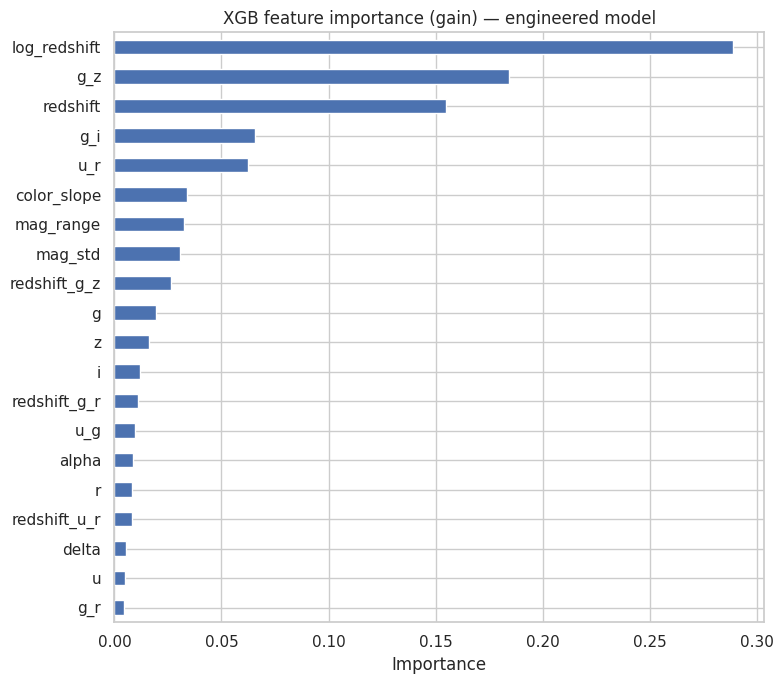

log_redshift   0.2890
g_z            0.1841
redshift       0.1546
g_i            0.0656
u_r            0.0624
color_slope    0.0339
mag_range      0.0326
mag_std        0.0304
redshift_g_z   0.0264
g              0.0192
z              0.0161
i              0.0119
redshift_g_r   0.0112
u_g            0.0094
alpha          0.0084
r              0.0083
redshift_u_r   0.0082
delta          0.0055
u              0.0049
g_r            0.0046
dtype: float32

In [27]:
# Train één model op volledige trainset voor feature importance
w_full = compute_sample_weight('balanced', y)
m_full = XGBClassifier(**XGB_PARAMS)
m_full.fit(X_eng, y, sample_weight=w_full)

imp = pd.Series(m_full.feature_importances_, index=X_eng.columns)
imp = imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
imp.head(20).plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_title('XGB feature importance (gain) — engineered model')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

imp.head(20)